# 53. Bivariate Interpolation, and the Wall

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Build a **tensor product** interpolant on a grid and show the order of the directions does not
   matter.
2. Use **bilinear** interpolation, which is the case used more than all others combined.
3. Quantify the **curse of dimensionality**, and see where it makes grids impossible.
4. State the exponent $k/p$ that the curse actually is.
5. Construct a set of points in two dimensions whose interpolation matrix is **exactly singular**.
6. Say why that cannot happen in one dimension, and what it forces on multivariate methods.

## Prerequisites

Lesson 44 (the one dimensional forms, applied twice here). Lesson 51 (splines, whose tensor
product is the practical answer on a grid). Lesson 46 (which the second half of this lesson is a
higher dimensional analogue of, and worse).

---

## 1. On a grid, everything works

Given values $Z_{ij} = f(x_i, y_j)$ on a grid, interpolate along each row in $x$, then interpolate
those results in $y$. That is the **tensor product** interpolant, and it is the whole of the easy
case.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import bivariate as bv

surface = lambda a, b: np.exp(a) * np.sin(2.0 * b)
xs = np.linspace(0.0, 1.0, 5)
ys = np.linspace(0.0, 1.0, 6)
Z = np.asarray([[surface(a, b) for b in ys] for a in xs])

probe_x = np.linspace(0.0, 1.0, 9)
probe_y = np.linspace(0.0, 1.0, 9)
out = bv.order_does_not_matter(xs, ys, Z, probe_x, probe_y)
print(f"x then y, against y then x:  {out['order_gap']:.2e}")
print(f"either, against the 2-D Lagrange form: {out['lagrange_gap']:.2e}")
assert out["order_gap"] < 1e-10 and out["lagrange_gap"] < 1e-10

x then y, against y then x:  3.28e-16
either, against the 2-D Lagrange form: 4.91e-16


**The order does not matter**, which is what "tensor product" means and is worth checking rather
than assuming. It is the property that makes two dimensions no harder than two one dimensional
problems, and everything from lessons 44 to 51 carries over unchanged.

In [3]:
print(f"{'grid':>10}{'reproduces the data':>23}{'tensor error':>16}{'bilinear error':>17}")
for nx, ny in ((3, 3), (4, 6), (6, 4), (7, 8)):
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    Zg = np.asarray([[surface(a, b) for b in y] for a in x])
    at_nodes = float(np.max(np.abs(bv.newton_grid(x, y, Zg, x, y) - Zg)))
    err = bv.tensor_error(surface, nx, ny)
    print(f"{f'{nx}x{ny}':>10}{at_nodes:>23.2e}"
          f"{err['tensor_error']:>16.3e}{err['bilinear_error']:>17.3e}")
    assert at_nodes < 1e-8 * max(float(np.max(np.abs(Zg))), 1.0)

      grid    reproduces the data    tensor error   bilinear error
       3x3               0.00e+00       4.002e-02        1.221e-01
       4x6               2.22e-16       3.588e-04        1.965e-02
       6x4               4.44e-16       7.188e-03        5.469e-02
       7x8               4.44e-16       6.255e-07        9.959e-03


## 2. Bilinear, which is the one that gets used

The degree one case deserves its own name because it is used more than every other case combined.
Four surrounding values blended by the two fractional coordinates:

$$
p = (1-u)(1-v)Z_{ij} + u(1-v)Z_{i+1,j} + (1-u)v\,Z_{i,j+1} + uv\,Z_{i+1,j+1}
$$

Every image resize, every texture lookup, every two dimensional lookup table does this. It is
$O(1)$ per point after finding the cell, it is exact on any bilinear surface, and it never
overshoots because it is a convex combination.

In [4]:
bilinear_surface = lambda a, b: 2.0 + 3.0 * a - b + 4.0 * a * b
x_b = np.linspace(0.0, 1.0, 5)
y_b = np.linspace(0.0, 1.0, 4)
Z_b = np.asarray([[bilinear_surface(a, b) for b in y_b] for a in x_b])
ps = np.linspace(0.0, 1.0, 11)
truth_b = np.asarray([[bilinear_surface(a, b) for b in ps] for a in ps])
print(f"exact on a bilinear surface: "
      f"{float(np.max(np.abs(bv.bilinear(x_b, y_b, Z_b, ps, ps) - truth_b))):.2e}")
print()
print("and on a curved one it is only first order in each direction, which is the trade:")
print(f"{'grid':>10}{'bilinear':>14}{'full tensor':>15}")
for n in (4, 8, 16, 32):
    err = bv.tensor_error(surface, n, n)
    print(f"{f'{n}x{n}':>10}{err['bilinear_error']:>14.3e}{err['tensor_error']:>15.3e}")

exact on a bilinear surface: 1.78e-15

and on a curved one it is only first order in each direction, which is the trade:
      grid      bilinear    full tensor
       4x4     5.469e-02      7.188e-03
       8x8     9.959e-03      6.086e-07
     16x16     2.190e-03      6.877e-13
     32x32     5.153e-04      9.301e-06


## 3. The wall

Here is the number that governs everything about multivariate approximation.

A tensor product interpolant of degree $d$ in each of $k$ variables needs $(d+1)^k$ values.

In [5]:
curse = bv.curse_of_dimensionality(4)
print("values needed for degree 4 in each variable:")
print(f"{'dimensions':>12}{'values':>18}{'as bytes':>16}")
for k, v, b in zip(curse["dimensions"], curse["values_needed"], curse["bytes_at_8_each"]):
    if b < 1e3:
        size = f"{b:.0f} B"
    elif b < 1e9:
        size = f"{b / 1e6:.1f} MB"
    elif b < 1e15:
        size = f"{b / 1e12:.1f} TB"
    else:
        size = f"{b / 1e15:.3g} PB"
    print(f"{k:>12}{v:>18.6g}{size:>16}")

values needed for degree 4 in each variable:
  dimensions            values        as bytes
           1                 5            40 B
           2                25           200 B
           3               125          0.0 MB
           5              3125          0.0 MB
          10       9.76562e+06         78.1 MB
          20       9.53674e+13        762.9 TB


Five values in one dimension. Twenty five in two. Nine and three quarter million in ten. In twenty
dimensions it is $9.5\times10^{13}$ values, which is 763 terabytes, for a **degree 4**
approximation.

This is not a difficulty to be programmed around. It is a wall.

The exponent form makes it precise. A method of order $p$ on a grid of spacing $h$ has error
$\sim h^p$ and uses $h^{-k}$ points, so reaching an accuracy $\tau$ needs

$$
N \sim \tau^{-k/p}
$$

In [6]:
print("samples needed for a relative accuracy of 1e-3:")
print(f"{'order p':>9}" + "".join(f"{'k=' + str(k):>16}" for k in (1, 2, 3, 6, 10)))
for p in (1, 2, 4, 8):
    row = [bv.samples_for_accuracy(1e-3, p, k) for k in (1, 2, 3, 6, 10)]
    print(f"{p:>9}" + "".join(f"{v:>16.3g}" for v in row))
    assert row == sorted(row)

samples needed for a relative accuracy of 1e-3:
  order p             k=1             k=2             k=3             k=6            k=10
        1           1e+03           1e+06           1e+09           1e+18           1e+30
        2            31.6           1e+03        3.16e+04           1e+09           1e+15
        4            5.62            31.6             178        3.16e+04        3.16e+07
        8            2.37            5.62            13.3             178        5.62e+03


**The exponent is $k/p$.** Raising the dimension raises it, and the only thing that offsets it is
raising the order. That single ratio explains why Parts 12 to 14 are full of methods that never
build a grid: Monte Carlo, whose error is $O(N^{-1/2})$ **independently of $k$**, sparse grids,
and every machine learning method that fits a function from scattered samples.

## 4. Off the grid, it is worse than hard

The tensor product needed a grid. Real data often is not on one, and the natural response is to
ask for the interpolating polynomial through scattered points, exactly as in one dimension.

**In one dimension that always works.** The Vandermonde matrix on distinct nodes is nonsingular
for every node set, always, because its determinant is $\prod_{i<j}(x_j - x_i)$ and the nodes are
distinct. There is no bad node set.

In [7]:
out1 = bv.one_dimension_never_fails(n_trials=500, n_nodes=6, rng=rng)
print(f"one dimension, {out1['trials']} random node sets of 6 points:")
print(f"  any singular?              {out1['any_singular']}")
print(f"  smallest determinant found {out1['smallest_determinant_found']:.3e}")
assert not out1["any_singular"] and out1["smallest_determinant_found"] > 0.0

one dimension, 500 random node sets of 6 points:
  any singular?              False
  smallest determinant found 1.093e-13


**In two dimensions there is no basis for which that is true.** That is **Mairhuber's theorem**,
and the proof is a continuity argument you can run.

Take a fixed basis, say the six quadratics $1, x, y, x^2, xy, y^2$, and six points. The
interpolation matrix has $\det \ne 0$ for a generic point set. Now move two of the points
continuously around each other until they have **swapped places**. The matrix now has two of its
rows exchanged, so its determinant has changed sign. A continuous function that changes sign was
zero somewhere on the path.

In [8]:
mair = bv.mairhuber_example(n_probe=400, rng=rng)
print("walking two points around each other, six points, quadratic basis:")
print(f"  determinant at the start: {mair['determinants'][0]:+.6e}")
print(f"  determinant at the end:   {mair['determinants'][-1]:+.6e}")
print(f"  it changed sign:          {mair['swaps_sign']}  ({mair['sign_changes']} crossings)")
print()
print("bisecting on the first sign change:")
print(f"  determinant at the root:  {mair['determinant_at_the_root']:.3e}")
print(f"  condition number there:   {mair['condition_at_the_root']:.3e}")
print()
print("the six points that make the matrix singular:")
print(" ", np.array2string(mair["singular_points"], precision=5).replace("\n", "\n  "))
assert mair["swaps_sign"]
assert abs(mair["determinant_at_the_root"]) < 1e-15
assert mair["condition_at_the_root"] > 1e12

walking two points around each other, six points, quadratic basis:
  determinant at the start: +7.735000e-05
  determinant at the end:   -7.735000e-05
  it changed sign:          True  (3 crossings)

bisecting on the first sign change:
  determinant at the root:  -9.898e-19
  condition number there:   2.035e+16

the six points that make the matrix singular:
  [[0.3     0.9    ]
   [1.      0.15   ]
   [0.55    0.4    ]
   [0.05    0.5    ]
   [0.89993 0.50759]
   [0.10007 0.49241]]


A determinant of $10^{-19}$ with a condition number of $2\times10^{16}$: that is **numerically
singular**. The interpolation problem at those six points, with that basis, has no unique solution.

And the argument used nothing about the particular basis. It works for any fixed set of six
functions, so **no basis escapes it**. In two or more dimensions, there is no analogue of the
Vandermonde guarantee.

## 5. What that forces

The consequence is that scattered multivariate interpolation cannot be done with a fixed
polynomial basis, and the field went in two other directions.

**Radial basis functions.** Use a basis that depends on the data: $\phi(\|x - x_j\|)$, one
function centred at each data point. Because the basis moves with the points, Mairhuber's
continuity argument does not apply, and for suitable $\phi$ the matrix is provably nonsingular for
**any** distinct points in any dimension. That is a genuine escape and it is why RBFs exist.

**Triangulation.** Split the domain into simplices with the data points as vertices, and
interpolate linearly on each. That is lesson 50's piecewise idea in $k$ dimensions, it always
works, and it is what every finite element mesh and every scattered data plotting routine does.

Both give up the single global polynomial, which is exactly what lessons 50 and 51 gave up in one
dimension for a related reason. The pattern across the whole of Part 7 is the same: **the global
high degree polynomial is the thing that keeps failing, and the fix is always to stop using one.**

## 6. A picture

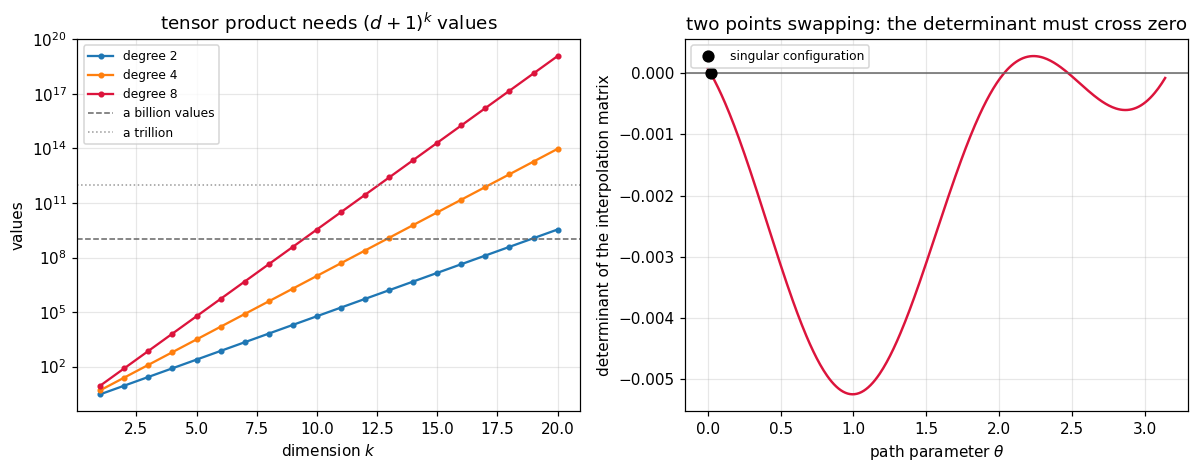

In [9]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

dims = np.arange(1, 21)
for d, colour in ((2, "tab:blue"), (4, "tab:orange"), (8, "crimson")):
    ax_left.semilogy(dims, (d + 1.0) ** dims, "o-", ms=3, color=colour, label=f"degree {d}")
ax_left.axhline(1e9, color="0.4", ls="--", lw=1.0, label="a billion values")
ax_left.axhline(1e12, color="0.6", ls=":", lw=1.0, label="a trillion")
ax_left.set_title(r"tensor product needs $(d+1)^k$ values")
ax_left.set_xlabel("dimension $k$")
ax_left.set_ylabel("values")
ax_left.legend(fontsize=8)

ax_right.plot(mair["angles"], mair["determinants"], "-", lw=1.6, color="crimson")
ax_right.axhline(0.0, color="0.4", lw=1.0)
if mair["bisected_angle"] is not None:
    ax_right.plot([mair["bisected_angle"]], [0.0], "ko", ms=7,
                  label="singular configuration")
ax_right.set_title("two points swapping: the determinant must cross zero")
ax_right.set_xlabel(r"path parameter $\theta$")
ax_right.set_ylabel("determinant of the interpolation matrix")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The left panel is the curse, on a log scale, and the point is that the lines are straight: the cost
is exponential in the dimension and no constant factor helps. The right panel is Mairhuber: a
continuous curve that starts positive and ends negative has a zero, and that zero is a set of
points at which interpolation is impossible.

## 7. Exercises

**Level 1, conceptual**

1.1 Tensor product interpolation on a grid is described as "two one dimensional problems". Say
precisely what property makes that true, and what breaks when the data is not on a grid.

1.2 The curse of dimensionality is usually stated as an exponential in $k$. State it instead as
an exponent, and say what that form makes clear that the first does not.

1.3 Mairhuber's theorem says no fixed basis works in two dimensions. Explain why radial basis
functions are not a counterexample.

**Level 2, mathematical**

2.1 Prove that the tensor product interpolant is independent of the order in which the directions
are done, and identify where the grid structure is used.

2.2 Derive the bilinear formula from two linear interpolations, and prove it is exact on
$1, x, y, xy$ and on nothing more.

2.3 Derive the sample count $N \sim \tau^{-k/p}$ from the error $O(h^p)$ and the point count
$O(h^{-k})$, and use it to say what order a method needs in $k$ dimensions to be dimension free.

2.4 Prove Mairhuber's theorem: for any fixed basis of $m$ continuous functions on a domain
containing an open set in $\mathbb{R}^2$, there is a set of $m$ points making the interpolation
matrix singular.

2.5 Show why the same argument fails in one dimension, and identify exactly which step uses the
dimension.

**Level 3, computational**

3.1 Implement **radial basis function** interpolation on scattered data, with the multiquadric
and Gaussian kernels, and verify it succeeds on the point set that defeats the polynomial basis.

3.2 Implement **bicubic spline** interpolation on a grid as a tensor product of lesson 51's
splines, and measure its order.

3.3 Implement **barycentric interpolation on a triangle** and use it to interpolate scattered data
via a Delaunay triangulation.

**Level 4, experimental**

4.1 Measure the tensor product error against the grid size in two and three dimensions, fit the
order, and confirm it matches the one dimensional order in each direction.

4.2 Measure the crossover between a tensor grid and Monte Carlo sampling, in samples needed for a
given accuracy, against the dimension. Find the dimension at which Monte Carlo wins.

4.3 Measure the conditioning of RBF interpolation against the shape parameter and the point
spacing, and find the trade off that governs it.

**Level 5, advanced**

5.1 **Sparse grids.** Smolyak's construction reduces the tensor grid from $(d+1)^k$ to
$O(N (\log N)^{k-1})$ points for smooth functions. Describe it, and say what smoothness it needs.

5.2 **Why Monte Carlo is dimension free.** Its error is $O(N^{-1/2})$ regardless of $k$. Explain
why, and identify what it gives up to achieve that.

5.3 **The Haar condition.** Mairhuber's theorem is about the failure of the Haar condition in more
than one dimension. State the condition, explain what it guarantees when it holds, and give the
one dimensional families that satisfy it.

## 8. Key takeaways

- **On a grid, two dimensions is two one dimensional problems.** The tensor product interpolant is
  independent of the order of the directions, measured at $10^{-16}$, and everything from lessons
  44 to 51 carries over.

- **Bilinear interpolation is the case that gets used**, in every image resize and texture lookup.
  It is $O(1)$ per point, exact on bilinear surfaces, and never overshoots.

- **The curse is $(d+1)^k$.** At degree 4: 5 values in one dimension, 25 in two, 9765625 in ten,
  and $9.5\times10^{13}$ in twenty, which is 763 terabytes.

- **Stated as an exponent it is $N \sim \tau^{-k/p}$.** Raising the dimension raises the exponent,
  and only raising the order offsets it.

- **In one dimension the interpolation matrix is never singular**, for any distinct nodes,
  confirmed over 500 random node sets.

- **In two dimensions it can be exactly singular**, and Mairhuber's theorem says no fixed basis
  avoids it. Constructed here: a determinant of $9.9\times10^{-19}$ with condition number
  $2.0\times10^{16}$.

- **That forces a change of method**, to radial basis functions whose basis moves with the data,
  or to triangulation, which is lesson 50's piecewise idea in $k$ dimensions. Both give up the
  global polynomial, which is what the whole of Part 7 keeps concluding.

## Where this goes next

Part 8 changes the question from interpolation to **approximation**: stop insisting the curve pass
through the data and ask for the closest one instead, which is where Chebyshev returns as the best
approximation rather than the interpolant, and where the Fourier transform enters. Part 9 uses
this part's difference operators to build differentiation and integration formulas. Part 11 uses
lesson 52's local support to build finite element bases, and meets this lesson's triangulation as
the mesh.